In [1]:
import pandas as pd
import numpy as np
import re
from scipy.stats import ttest_rel, wilcoxon
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load Recommendations

In [20]:
playlist_recommendation = pd.read_csv("dataset/recommendations_for_all_models_with_hybrid.csv")

In [21]:
def convert_string_array_to_list(s):
    """Convert a string representation of an array into a list of integers."""
    if isinstance(s, str):  # Handle string case (where it's incorrectly stored)
        numbers = re.findall(r'\d+', s)  # Extract all numeric values
        return [int(x) for x in numbers]  # Convert to integers
    
    elif isinstance(s, np.ndarray):  # Handle NumPy array case
        return s.astype(int).tolist()
    
    elif isinstance(s, list):  # Handle lists with possible string numbers
        return [int(x) for x in s if str(x).isdigit()]
    
    return []  # Return empty list if the format is unexpected

# Apply function and debug output
playlist_recommendation['tracks_to_predict'] = playlist_recommendation['tracks_to_predict'].apply(lambda x: convert_string_array_to_list(x))
playlist_recommendation['random_recommendations'] = playlist_recommendation['random_recommendations'].apply(lambda x: convert_string_array_to_list(x))
playlist_recommendation['content_based_unweigted_recommendations'] = playlist_recommendation['content_based_unweigted_recommendations'].apply(lambda x: convert_string_array_to_list(x))
playlist_recommendation['content_based_weigted_recommendations'] = playlist_recommendation['content_based_weigted_recommendations'].apply(lambda x: convert_string_array_to_list(x))
playlist_recommendation['collaborative_filtering_recommendations'] = playlist_recommendation['collaborative_filtering_recommendations'].apply(lambda x: convert_string_array_to_list(x))
playlist_recommendation['hybrid_recommendations'] = playlist_recommendation['hybrid_recommendations'].apply(lambda x: convert_string_array_to_list(x))

playlist_recommendation.head()

,playlist_idx,cluster,tracks_to_predict,random_recommendations,collaborative_filtering_recommendations,content_based_unweigted_recommendations,content_based_weigted_recommendations,hybrid_recommendations
0,2,3,"[232845, 111887, 144160, 10663, 216321, 138869...","[174804, 45667, 180239, 72464, 155677, 131180,...","[174997, 175642, 186858, 72522, 111887, 55648,...","[26657, 102881, 169451, 97130, 76387, 177055, ...","[44021, 153676, 129186, 58351, 130032, 135471,...","[186858, 175642, 111887, 157693, 55648, 206871..."
1,7,1,"[48557, 142203, 66610, 16213, 112277, 43008, 2...","[205630, 246877, 130193, 36681, 90295, 118324,...","[191313, 111863, 163571, 89133, 216260, 237774...","[121753, 168149, 245519, 129186, 140469, 10137...","[102680, 129186, 147304, 60873, 229551, 194684...","[191313, 111863, 163571, 216260, 89133, 237774..."
2,10,0,"[89301, 74022, 221104, 218307, 229795, 129045,...","[123988, 154415, 107915, 207660, 19850, 7725, ...","[208248, 94251, 218307, 122853, 212881, 221104...","[137497, 208248, 83517, 3939, 26659, 234445, 6...","[208248, 232281, 144800, 240182, 44263, 63352,...","[208248, 94251, 218307, 122853, 8706, 212881, ..."
3,17,2,"[131069, 102197, 241039, 46103, 41621, 213083,...","[117021, 227150, 234857, 240503, 162330, 37045...","[235367, 216374, 237415, 64550, 250306, 140314...","[237818, 208248, 156298, 237495, 194633, 25030...","[237818, 123797, 237495, 156298, 31218, 149917...","[235367, 216374, 237415, 64550, 54047, 14975, ..."
4,28,2,"[166174, 63352, 37636, 75383, 195511, 131429, ...","[234157, 246389, 216575, 93478, 6884, 97278, 3...","[250306, 26659, 86790, 167186, 180201, 64550, ...","[29052, 26659, 251276, 208248, 234445, 250306,...","[26659, 234445, 251276, 250306, 245084, 29052,...","[250306, 26659, 86790, 167186, 64550, 180201, ..."


# Code for Evaluation

In [22]:
def compute_metrics_for_playlist(predicted_tracks, test_indices, k):
    top_k = predicted_tracks[:k]  # Consider only top K predictions

    # Hit@K
    hit = int(any(t in top_k for t in test_indices))

    # MRR and AP calculations
    precisions = []
    num_hits = 0
    mrr = 0.0

    for rank_idx, track_idx in enumerate(top_k):
        if track_idx in test_indices:
            num_hits += 1
            precision_at_k = num_hits / (rank_idx + 1)
            precisions.append(precision_at_k)
            if mrr == 0.0:
                mrr = 1.0 / (rank_idx + 1)

    ap = np.mean(precisions) if precisions else 0.0

    return hit, mrr, ap

def evaluate_model(playlist, column_name, k):
    num_playlists = len(playlist)

    hit_total, mrr_total, ap_total = 0, 0, 0

    for idx, row in playlist.iterrows():
        test_indices = row['tracks_to_predict']
        predicted_tracks = row[column_name]

        hit, mrr, ap = compute_metrics_for_playlist(predicted_tracks, test_indices, k)
        
        hit_total += hit
        mrr_total += mrr
        ap_total += ap

    # Compute averages
    hit_ratio = hit_total / num_playlists if num_playlists > 0 else 0
    mrr_avg = mrr_total / num_playlists if num_playlists > 0 else 0
    map_avg = ap_total / num_playlists if num_playlists > 0 else 0

    return hit_ratio, mrr_avg, map_avg, column_name

def evaluate_model_hypo(playlist, column_name, k, return_all=False):
    hits, mrrs, aps = [], [], []

    for idx, row in playlist.iterrows():
        test_indices = row['tracks_to_predict']
        predicted_tracks = row[column_name]

        hit, mrr, ap = compute_metrics_for_playlist(predicted_tracks, test_indices, k)
        
        hits.append(hit)
        mrrs.append(mrr)
        aps.append(ap)

    if return_all:
        return hits, mrrs, aps  # return lists for paired testing
    else:
        num_playlists = len(hits)
        hit_ratio = sum(hits) / num_playlists if num_playlists > 0 else 0
        mrr_avg = sum(mrrs) / num_playlists if num_playlists > 0 else 0
        map_avg = sum(aps) / num_playlists if num_playlists > 0 else 0
        return hit_ratio, mrr_avg, map_avg, column_name

def compare_models(playlist, model_a_col, model_b_col, k):
    # Get per-playlist metrics
    hits_a, mrrs_a, aps_a = evaluate_model_hypo(playlist, model_a_col, k, return_all=True)
    hits_b, mrrs_b, aps_b = evaluate_model_hypo(playlist, model_b_col, k, return_all=True)

    # Paired t-tests
    t_hit, p_hit = ttest_rel(hits_a, hits_b)
    t_mrr, p_mrr = ttest_rel(mrrs_a, mrrs_b)
    t_ap, p_ap = ttest_rel(aps_a, aps_b)

    return {
        "Hit@K": {"t-stat": t_hit, "p-value": p_hit},
        "MRR": {"t-stat": t_mrr, "p-value": p_mrr},
        "MAP": {"t-stat": t_ap, "p-value": p_ap}
    }

def evaluate_model_by_cluster(playlist, column_name, k, cluster_column):
    # Group by the cluster column
    clusters = playlist.groupby(cluster_column)
    
    cluster_metrics = {}

    for cluster, cluster_data in clusters:
        # Initialize total metrics for the current cluster
        hit_total, mrr_total, ap_total = 0, 0, 0

        for idx, row in cluster_data.iterrows():
            test_indices = row['tracks_to_predict']
            predicted_tracks = row[column_name]

            hit, mrr, ap = compute_metrics_for_playlist(predicted_tracks, test_indices, k)

            hit_total += hit
            mrr_total += mrr
            ap_total += ap

        # Compute averages for the current cluster
        num_playlists = len(cluster_data)
        hit_ratio = hit_total / num_playlists if num_playlists > 0 else 0
        mrr_avg = mrr_total / num_playlists if num_playlists > 0 else 0
        map_avg = ap_total / num_playlists if num_playlists > 0 else 0

        # Store the metrics for the current cluster
        cluster_metrics[cluster] = {
            "Hit@K": hit_ratio,
            "MRR": mrr_avg,
            "MAP": map_avg
        }

    return cluster_metrics

def evaluate_row_metrics(row, column_name, k):
    test_indices = row['tracks_to_predict']
    predicted_tracks = row[column_name]

    hit, mrr, ap = compute_metrics_for_playlist(predicted_tracks, test_indices, k)
    
    return hit, mrr, ap

def create_metrics_dataframe(playlist, column_name, k, cluster_column):
    # Apply the evaluate_row_metrics function to each row
    metrics = playlist.apply(lambda row: evaluate_row_metrics(row, column_name, k), axis=1)
    
    # Create a new dataframe with the metrics
    metrics_df = pd.DataFrame(metrics.tolist(), columns=["Hit@K", "MRR", "MAP"])
    metrics_df[cluster_column] = playlist[cluster_column].values  # Add the cluster information

    return metrics_df

# Level 4: Comparing Hybrid Model against Content Based Model & Collaborative Filtering

## Model Performance

Hybrid Model

In [23]:
# Run evaluation
hit_ratio, mrr_avg, map_avg, column_name = evaluate_model(playlist_recommendation, 'hybrid_recommendations', k=50)

# Print results
print(f"Evaluation Metrics for {column_name}")
print(f"Hit@50: {hit_ratio:.4f}")
print(f"MRR: {mrr_avg:.4f}")
print(f"MAP@50: {map_avg:.4f}")

Evaluation Metrics for hybrid_recommendations
Hit@50: 0.5743
MRR: 0.1349
MAP@50: 0.0966


Content Based Model

In [24]:
# Run evaluation
hit_ratio, mrr_avg, map_avg, column_name = evaluate_model(playlist_recommendation, 'content_based_unweigted_recommendations', k=50)

# Print results
print(f"Evaluation Metrics for {column_name}")
print(f"Hit@50: {hit_ratio:.4f}")
print(f"MRR: {mrr_avg:.4f}")
print(f"MAP@50: {map_avg:.4f}")

Evaluation Metrics for content_based_unweigted_recommendations
Hit@50: 0.3582
MRR: 0.0757
MAP@50: 0.0613


Collaborative Filtering

In [25]:
# Run evaluation
hit_ratio, mrr_avg, map_avg, column_name = evaluate_model(playlist_recommendation, 'collaborative_filtering_recommendations', k=50)

# Print results
print(f"Evaluation Metrics for {column_name}")
print(f"Hit@50: {hit_ratio:.4f}")
print(f"MRR: {mrr_avg:.4f}")
print(f"MAP@50: {map_avg:.4f}")

Evaluation Metrics for collaborative_filtering_recommendations
Hit@50: 0.5673
MRR: 0.1372
MAP@50: 0.0982


## Hybrid Model vs Content Based

We will conduct a one-sided paired 2-sample hypothesis test at 5% level of significance

\begin{aligned}
H_0 &: \mu_{\text{content based}} \ge \mu_{\text{hybrid}} \quad \text{(Content based performs at least as well as hybrid)} \\
H_1 &: \mu_{\text{content based}} < \mu_{\text{hybrid}} \quad \text{(Hybrid performs better than content based)}
\end{aligned}

In [26]:
results = compare_models(
    playlist_recommendation,
    "content_based_unweigted_recommendations",
    "hybrid_recommendations",
    k=50
)

alpha = 0.05  # significance level

print("Hypothesis Test between Content Based vs Hybrid Model")

for metric, res in results.items():
    t_stat = res['t-stat']
    two_sided_p_val = res['p-value']
    one_sided_p_val = two_sided_p_val / 2

    print(f"\n=== {metric} Comparison ===")
    print(f"t-statistic: {t_stat:.3f}")
    print(f"one-sided p-value: {one_sided_p_val:.4f}")

Hypothesis Test between Content Based vs Hybrid Model

=== Hit@K Comparison ===
t-statistic: -16.118
one-sided p-value: 0.0000

=== MRR Comparison ===
t-statistic: -8.711
one-sided p-value: 0.0000

=== MAP Comparison ===
t-statistic: -7.341
one-sided p-value: 0.0000


Since the p-value for all 3 metrics are close to 0, we can reject the null hypothesis and conclude that the hybrid model performs better than the content based.

## Hybrid Model vs Collaborative Filtering

We will conduct a one-sided paired 2-sample hypothesis test at 5% level of significance

\begin{aligned}
H_0 &: \mu_{\text{collaborative filtering}} \ge \mu_{\text{hybrid}} \quad \text{(Collaborative filtering performs at least as well as hybrid)} \\
H_1 &: \mu_{\text{collaborative filtering}} < \mu_{\text{hybrid}} \quad \text{(Hybrid performs better than Collaborative filtering)}
\end{aligned}

In [27]:
results = compare_models(
    playlist_recommendation,
    "collaborative_filtering_recommendations",
    "hybrid_recommendations",
    k=50
)

alpha = 0.05  # significance level

print("Hypothesis Test between Collaborative Filtering vs Hybrid Model")

for metric, res in results.items():
    t_stat = res['t-stat']
    two_sided_p_val = res['p-value']
    one_sided_p_val = two_sided_p_val / 2

    print(f"\n=== {metric} Comparison ===")
    print(f"t-statistic: {t_stat:.3f}")
    print(f"one-sided p-value: {one_sided_p_val:.4f}")

Hypothesis Test between Collaborative Filtering vs Hybrid Model

=== Hit@K Comparison ===
t-statistic: -1.822
one-sided p-value: 0.0343

=== MRR Comparison ===
t-statistic: 1.226
one-sided p-value: 0.1101

=== MAP Comparison ===
t-statistic: 1.230
one-sided p-value: 0.1094


p-value for Hit@K is < 0.05, but the p-value for MRR and MAP is > 0.05 (although it is still not large). 

Therefore, we are unable to reject the null hypothesis and conclude thay the collaborative filtering performs at least as well as the hybrid model.

However, the hybrid model is more flexible, and able to combine the strengths of both content based and collaborative filtering.

As shown in level 3 analysis, the content based and collaborative filtering performance differs based on the cluster.

As such, we will continue to use the hybrid model.

## Limitations with Accuracy Metrics

Fill in the limitations here

## New Behavioural Metrics

Introduce and explain what the metrics does here

## Model Performance using Behavioural Metrics

### Load Datasets

In [28]:
tracks = pd.read_csv("dataset/tracks_new.csv")
playlist_original = pd.read_csv("dataset/playlist_final_final.csv")

### Manipulation

In [29]:
tracks['track_popularity'] = tracks['track_popularity'] / 100
tracks['track_idx'] = tracks['track_idx'].astype(int)
tracks = tracks.set_index('track_idx')
playlist_original['popularity_mean'] = playlist_original['popularity_mean'] / 100
playlist_original['playlist_idx'] = playlist_original['playlist_idx'].astype(int)
behavioural_scores = playlist_recommendation[['playlist_idx', 'cluster', 'tracks_to_predict']]

In [30]:
tracks_relevant_columns = tracks[['track_popularity',
                                  'Early Years', 'Classic Era', 'Golden Era', '2000s', 'Modern Era',
                                  'Short', 'Medium', 'Long',
                                  "joy", "calm", "sadness", "fear", "energizing", "dreamy",
                                  "Instrumental / Ambient Sounds", "Soft Acoustic / Classical", "Orchestral / Soundtrack", "Mid-tempo Pop / Indie", "Upbeat Electronic / Dance", "Slow & Melancholic (Sad Songs)", "Experimental / Jazz Fusion", "Lo-Fi / Chill Vibes"]]

In [31]:
playlist_original['sentiment_centroid'] = playlist_original['sentiment_centroid'].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))
playlist_original['genre_centroid'] = playlist_original['genre_centroid'].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

# Unpack the column into separate columns
playlist_original[['genre1', 'genre2', 'genre3', 'genre4', 'genre5', 'genre6', 'genre7', 'genre8']] = pd.DataFrame(playlist_original['genre_centroid'].tolist())

# Drop the original column if you no longer need it
playlist_original = playlist_original.drop(columns=['genre_centroid'])

# Unpack the column into separate columns
playlist_original[['sent1', 'sent2', 'sent3', 'sent4', 'sent5', 'sent6']] = pd.DataFrame(playlist_original['sentiment_centroid'].tolist())

# Drop the original column if you no longer need it
playlist_original = playlist_original.drop(columns=['sentiment_centroid'])

print(playlist_original)

playlist_relevant_columns = playlist_original[['popularity_mean', 
                                      'era_early_years_proportion', 'era_classic_era_proportion', 'era_golden_era_proportion', 'era_2000s_proportion', 'era_modern_era_proportion',
                                      'length_short_proportion', 'length_medium_proportion', 'length_long_proportion',
                                      'sent1', 'sent2', 'sent3', 'sent4', 'sent5', 'sent6',
                                      'genre1', 'genre2', 'genre3', 'genre4', 'genre5', 'genre6', 'genre7', 'genre8']]

playlist_original = playlist_original.set_index('playlist_idx')

       playlist_idx  cluster dataset_type  num_tracks  \
0                 1        1        train          32   
1                 2        3         test          10   
2                 3        3        train          52   
3                 4        0          val          64   
4                 5        0        final          73   
...             ...      ...          ...         ...   
18499         19995        1        train          59   
18500         19996        1        train         157   
18501         19997        1         test         161   
18502         19998        3          val         106   
18503         19999        1        final          90   

                                          track_idx_list  \
0      ['3689' '207774' '194775' '135193' '218011' '3...   
1      ['160375' '131195' '164629' '147280' '193891' ...   
2      ['104436' '229428' '25968' '186871' '81592' '1...   
3      ['244173' '210510' '9349' '224202' '147251' '3...   
4      ['194410

### Code for Evaluation

In [32]:
from sklearn.metrics.pairwise import cosine_similarity

def avg_cosine_similarity(set_a, set_b, tracks_df, track_feat_columns):
    """
    Computes the average cosine similarity between all track pairs (a, b)
    where a ∈ set_a and b ∈ set_b, based on the provided track feature columns.
    """
    # Convert set_a and set_b to list if they are not already
    set_a = list(set_a)
    set_b = list(set_b)
    
    # Make sure that the track indices are valid
    a_vectors = tracks_df.loc[set_a, track_feat_columns].values
    b_vectors = tracks_df.loc[set_b, track_feat_columns].values
    
    if a_vectors.shape[0] == 0 or b_vectors.shape[0] == 0:
        return 0.0  # Avoid similarity calculation if vectors are empty

    # Compute the cosine similarity between all pairs of tracks in a_vectors and b_vectors
    sim_matrix = cosine_similarity(a_vectors, b_vectors)
    return sim_matrix.mean()

# Example: To apply this on each playlist
def compute_relevance_for_playlist(row, tracks_df, track_feat_columns):
    true_tracks = row['tracks_to_predict']
    recommended_tracks = row['hybrid_recommendations']
    
    # Calculate cosine similarity for the top k recommended tracks and true tracks
    sim_score = avg_cosine_similarity(recommended_tracks, true_tracks, tracks_df, track_feat_columns)
    return sim_score

def calculate_diversity_score(recommended_tracks, tracks_df, track_feat_columns):
    """
    Calculate the diversity score for a given set of recommended tracks.
    The diversity score is based on the average pairwise cosine similarity between recommended tracks.
    A lower cosine similarity indicates higher diversity.
    """
    # Extract the feature vectors of the recommended tracks
    recommended_vectors = tracks_df.loc[recommended_tracks, track_feat_columns].values
    
    if recommended_vectors.shape[0] == 0:
        return 0.0  # If there are no recommended tracks, return a default score
    
    # Compute the pairwise cosine similarity between all recommended tracks
    sim_matrix = cosine_similarity(recommended_vectors)
    
    # We remove the diagonal of the similarity matrix, as it represents self-similarity
    np.fill_diagonal(sim_matrix, 0)  # Set the diagonal to 0 to ignore self-similarity
    
    # Calculate the average of the off-diagonal similarities
    avg_similarity = sim_matrix.sum() / (sim_matrix.shape[0] * (sim_matrix.shape[0] - 1))
    
    # Diversity score: lower cosine similarity means higher diversity
    diversity_score = 1 - avg_similarity  # You can also directly return avg_similarity if you prefer
    
    return diversity_score

# Example: Apply this to each playlist
def compute_diversity_for_playlist(row, tracks_df, track_feat_columns):
    recommended_tracks = row['hybrid_recommendations']
    
    # Calculate the diversity score for the recommended tracks
    diversity_score = calculate_diversity_score(recommended_tracks, tracks_df, track_feat_columns)
    return diversity_score

def compute_novelty(row, playlist_relevant_df, tracks_df, playlist_feat_columns, track_feat_columns):
    # Get playlist feature vector (assume index of row matches that in playlist_relevant_df)
    playlist_vector = playlist_relevant_df.loc[row.name, playlist_feat_columns].values.reshape(1, -1)

    # Get track IDs for recommended tracks
    recommended_ids = row['hybrid_recommendations']
    
    # Make sure it's a list of valid indices
    recommended_ids = list(recommended_ids)
    
    # Get feature vectors for recommended tracks
    track_vectors = tracks_df.loc[recommended_ids, track_feat_columns].values
    
    if track_vectors.shape[0] == 0:
        return 0.0  # Avoid errors on empty recommended lists
    
    # Compute cosine similarity between playlist and each recommended track
    sim_scores = cosine_similarity(playlist_vector, track_vectors)[0]  # Shape (n_tracks,)
    
    # Novelty = 1 - average similarity
    novelty_score = 1 - np.mean(sim_scores)
    return novelty_score

### Model Performance

In [33]:
# Apply this to the dataset and create a new column in the `playlist_recommendation` DataFrame
behavioural_scores['relevance'] = playlist_recommendation.apply(compute_relevance_for_playlist, axis=1, 
                                               tracks_df=tracks, track_feat_columns=tracks_relevant_columns.columns)

print("Behaviorial Metrics of Hybrid Model:\n")

# Print the updated DataFrame
print("Mean relevance:", behavioural_scores['relevance'].mean())

# Apply this function to the playlist_recommendation DataFrame to get the diversity score for each playlist
behavioural_scores['diversity'] = playlist_recommendation.apply(compute_diversity_for_playlist, axis=1, 
                                          tracks_df=tracks, track_feat_columns=tracks_relevant_columns.columns)

# Print the dataframe with the diversity scores
print("Mean diversity:", behavioural_scores['diversity'].mean())

# Align indices
playlist_recommendation = playlist_recommendation.reset_index(drop=True)
playlist_original = playlist_original.reset_index(drop=True)

behavioural_scores['novelty'] = playlist_recommendation.apply(
    compute_novelty,
    axis=1,
    playlist_relevant_df=playlist_original,
    tracks_df=tracks,
    playlist_feat_columns=playlist_relevant_columns.columns,
    track_feat_columns=tracks_relevant_columns.columns
)

behavioural_scores['serendipity'] = behavioural_scores['relevance'] * behavioural_scores['novelty']

print("Mean serendipity:", behavioural_scores['serendipity'].mean())

Behaviorial Metrics of Hybrid Model:

Mean relevance: 0.5960463316965996
Mean diversity: 0.3651511018561783
Mean serendipity: 0.17822999207221144


# Level 5: Comparing Hybrid Model for Different Clusters

We have shown in Level 3 that our segmentation is effective. 

We will continue to explore if there are any significant differences using the behavioural metrics too, and the systematic reasons behind it.

In [34]:
metrics_df = pd.DataFrame({
    'Avg Relevance': behavioural_scores.groupby('cluster')['relevance'].mean(),
    'Avg Diversity': behavioural_scores.groupby('cluster')['diversity'].mean(),
    'Avg Serendipity': behavioural_scores.groupby('cluster')['serendipity'].mean()
})

print("Evaluation Metrics for Hybrid Model\n")

# Assuming metrics_df is already defined as before
for cluster in metrics_df.index:
    rel = metrics_df.loc[cluster, "Avg Relevance"]
    div = metrics_df.loc[cluster, "Avg Diversity"]
    ser = metrics_df.loc[cluster, "Avg Serendipity"]

    print(f"Metrics for Cluster {cluster}:")
    print(f"Avg Relevance: {rel:.4f}")
    print(f"Avg Diversity: {div:.4f}")
    print(f"Avg Serendipity: {ser:.4f}\n")

Evaluation Metrics for Hybrid Model

Metrics for Cluster 0:
Avg Relevance: 0.6376
Avg Diversity: 0.3218
Avg Serendipity: 0.1868

Metrics for Cluster 1:
Avg Relevance: 0.6243
Avg Diversity: 0.3426
Avg Serendipity: 0.1701

Metrics for Cluster 2:
Avg Relevance: 0.6400
Avg Diversity: 0.3319
Avg Serendipity: 0.1695

Metrics for Cluster 3:
Avg Relevance: 0.4868
Avg Diversity: 0.4560
Avg Serendipity: 0.1941



## F-Test

\begin{aligned}
H_0 &: \mu_{\text{cluster 0}} = \mu_{\text{cluster 1}} = \mu_{\text{cluster 2}} = \mu_{\text{cluster 3}} \quad \text{(No significant difference in the means of the metric across clusters)} \\
H_1 &: \text{At least one } \mu_i \neq \mu_j \quad \text{for some } i \neq j \quad \text{(There is a significant difference in the means of the metric across clusters)}
\end{aligned}

In [35]:
from scipy.stats import f_oneway

# Group the data by the cluster column
grouped = behavioural_scores.groupby('cluster')

# Prepare lists to store values for each behavioral metric
relevance_values = []
diversity_values = []
serendipity_values = []

for cluster, group in grouped:
    relevance_values.append(group["relevance"].values)
    diversity_values.append(group["diversity"].values)
    serendipity_values.append(group["serendipity"].values)

print("F Test between clusters in Behavioral Scores")

# Perform F-tests (ANOVA) for each metric
try:
    f_relevance, p_relevance = f_oneway(*relevance_values)
    f_diversity, p_diversity = f_oneway(*diversity_values)
    f_serendipity, p_serendipity = f_oneway(*serendipity_values)

    # Print the results of the F-tests
    results = {
        "Relevance": {"F-stat": f_relevance, "p-value": p_relevance},
        "Diversity": {"F-stat": f_diversity, "p-value": p_diversity},
        "Serendipity": {"F-stat": f_serendipity, "p-value": p_serendipity}
    }

    for metric, res in results.items():
        f_stat = res['F-stat']
        p_val = res['p-value']

        print(f"\n=== {metric} F-test ===")
        print(f"F-statistic: {f_stat:.3f}")
        print(f"p-value: {p_val:.4f}")
except ValueError as e:
    print(f"Error performing F-test: {e}. Possibly due to insufficient data in one or more clusters.")


F Test between clusters in Behavioral Scores

=== Relevance F-test ===
F-statistic: 420.134
p-value: 0.0000

=== Diversity F-test ===
F-statistic: 351.450
p-value: 0.0000

=== Serendipity F-test ===
F-statistic: 16.408
p-value: 0.0000


Since the p-value for all 3 metrics are close to 0, we reject the null hypothesis, and conclude that there is a significant difference in the metrics for each cluster.

## Clustered Barplot

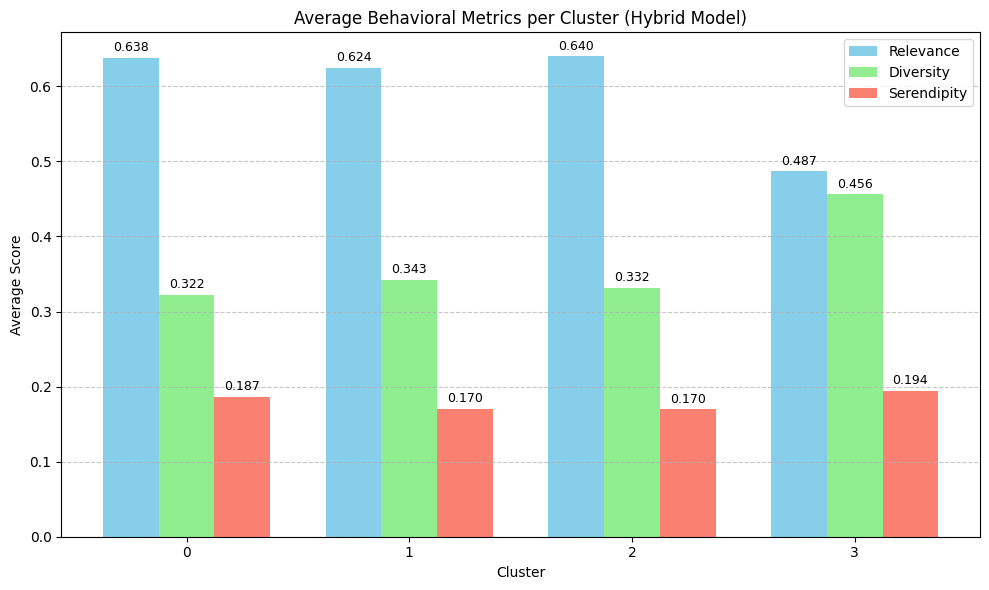

In [36]:
import matplotlib.pyplot as plt

# Reset index to bring cluster as a column for plotting
plot_df = metrics_df.reset_index()

# Set plot size and figure
plt.figure(figsize=(10, 6))

# Bar width and positions
bar_width = 0.25
clusters = plot_df['cluster']
x = range(len(clusters))

# Positions for each metric
x_relevance = [i - bar_width for i in x]
x_diversity = x
x_serendipity = [i + bar_width for i in x]

# Plot bars
bars_relevance = plt.bar(x_relevance, plot_df['Avg Relevance'], width=bar_width, label='Relevance', color='skyblue')
bars_diversity = plt.bar(x_diversity, plot_df['Avg Diversity'], width=bar_width, label='Diversity', color='lightgreen')
bars_serendipity = plt.bar(x_serendipity, plot_df['Avg Serendipity'], width=bar_width, label='Serendipity', color='salmon')

# Add labels on top of each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f'{height:.3f}', 
                 ha='center', va='bottom', fontsize=9)

add_labels(bars_relevance)
add_labels(bars_diversity)
add_labels(bars_serendipity)

# Labeling
plt.xlabel('Cluster')
plt.ylabel('Average Score')
plt.title('Average Behavioral Metrics per Cluster (Hybrid Model)')
plt.xticks(ticks=x, labels=clusters)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

## Observations & Reason for difference

Fill in the observations, that for each model, the relative performance are different for the different clusters

# Conclusion

In the next level, we will finally adjust the weights for the hybrid model (Content-Based & Collaborative Filtering), and the feature weights to achieve desired scores for each cluster based on their nature.